In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../datasets/AmesHousing.csv')

In [3]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [5]:
df.isnull().sum()*100

Order                 0
PID                   0
MS SubClass           0
MS Zoning             0
Lot Frontage      49000
                  ...  
Mo Sold               0
Yr Sold               0
Sale Type             0
Sale Condition        0
SalePrice             0
Length: 82, dtype: int64

In [6]:
(df.isnull().mean()*100)[df.isnull().sum()>0]

Lot Frontage      16.723549
Alley             93.242321
Mas Vnr Type      60.580205
Mas Vnr Area       0.784983
Bsmt Qual          2.730375
Bsmt Cond          2.730375
Bsmt Exposure      2.832765
BsmtFin Type 1     2.730375
BsmtFin SF 1       0.034130
BsmtFin Type 2     2.764505
BsmtFin SF 2       0.034130
Bsmt Unf SF        0.034130
Total Bsmt SF      0.034130
Electrical         0.034130
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
Fireplace Qu      48.532423
Garage Type        5.358362
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Cars        0.034130
Garage Area        0.034130
Garage Qual        5.426621
Garage Cond        5.426621
Pool QC           99.556314
Fence             80.477816
Misc Feature      96.382253
dtype: float64

In [7]:
df['Garage Type'].value_counts()

Garage Type
Attchd     1731
Detchd      782
BuiltIn     186
Basment      36
2Types       23
CarPort      15
Name: count, dtype: int64

<Axes: xlabel='Garage Type'>

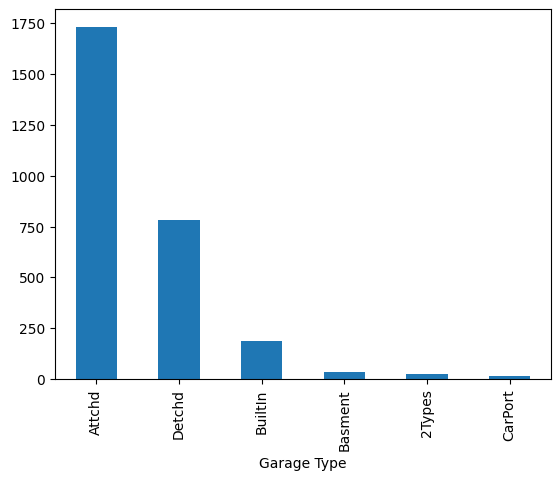

In [8]:
df['Garage Type'].value_counts().plot(kind='bar')

In [9]:
df['Garage Type'].fillna('Missing',inplace=True)
#Inplace = True ensures that a new column is not created and the existin one is edited

/var/folders/4r/r54s3_591ybgs6zwhwsjs1z00000gn/T/ipykernel_59747/689540332.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Garage Type'].fillna('Missing',inplace=True)


<Axes: xlabel='Garage Type'>

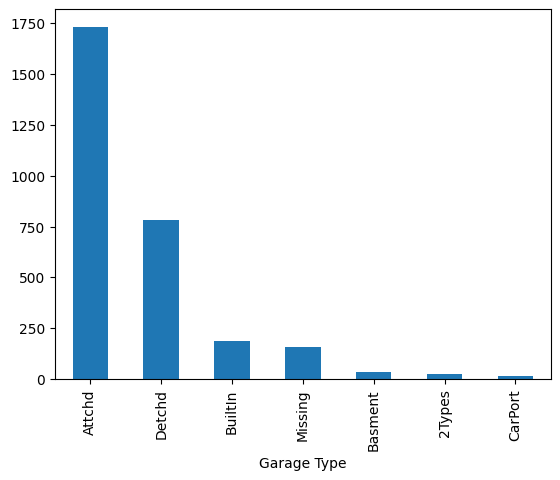

In [10]:
df['Garage Type'].value_counts().plot(kind='bar')

In [11]:
df['Garage Type'] = df['Garage Type'].replace('Missing', np.nan)

In [12]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [14]:
from sklearn.impute import SimpleImputer

In [15]:
impute = SimpleImputer(strategy='constant', fill_value='Missing')

In [16]:
X_train['Garage Type'].value_counts()

Garage Type
Attchd     1388
Detchd      623
BuiltIn     152
Basment      27
2Types       17
CarPort      14
Name: count, dtype: int64

In [17]:
X_train[['Garage Type']] = impute.fit_transform(X_train[['Garage Type']])
X_test[['Garage Type']] = impute.transform(X_test[['Garage Type']])

In [18]:
X_train['Garage Type'].sample(5)

2804    Attchd
1678    Detchd
1946    Detchd
997     Attchd
2258    Attchd
Name: Garage Type, dtype: object

In [19]:
impute.statistics_

array(['Missing'], dtype=object)

In [20]:
#Now using a different stratergy i.e. most frequent

In [21]:
df['Garage Type'].mode()

0    Attchd
Name: Garage Type, dtype: object

In [22]:
df['Garage Type'].value_counts(dropna=False)

Garage Type
Attchd     1731
Detchd      782
BuiltIn     186
NaN         157
Basment      36
2Types       23
CarPort      15
Name: count, dtype: int64

<Axes: xlabel='Garage Type'>

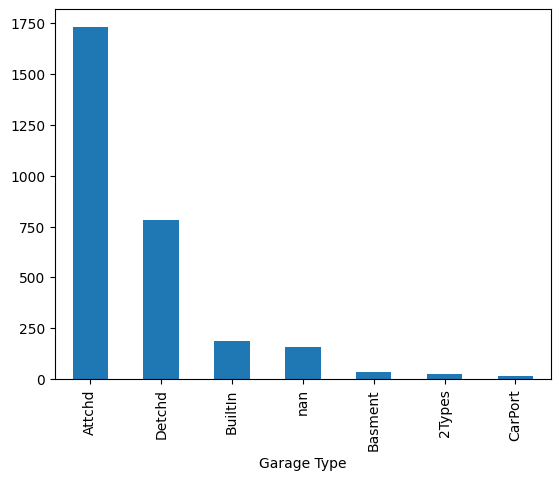

In [23]:
df['Garage Type'].value_counts(dropna=False).plot(kind='bar')

/var/folders/4r/r54s3_591ybgs6zwhwsjs1z00000gn/T/ipykernel_59747/2798646861.py:8: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(lines,labels=['Attchd','Null'],loc='best')


Text(0.5, 1.0, 'Garage Type')

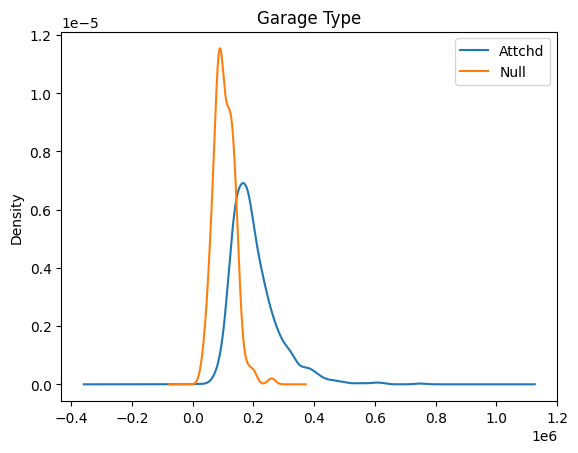

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['Garage Type']=='Attchd']['SalePrice'].plot(kind='kde',ax=ax)
df[df['Garage Type'].isnull()]['SalePrice'].plot(kind='kde',ax=ax)

lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels=['Attchd','Null'],loc='best')
plt.title('Garage Type')

In [25]:
temp = df[df['Garage Type']=='Attchd']['SalePrice']

In [26]:
df['Garage Type'].fillna('Attchd',inplace=True)

/var/folders/4r/r54s3_591ybgs6zwhwsjs1z00000gn/T/ipykernel_59747/3392253931.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Garage Type'].fillna('Attchd',inplace=True)


<Axes: xlabel='Garage Type'>

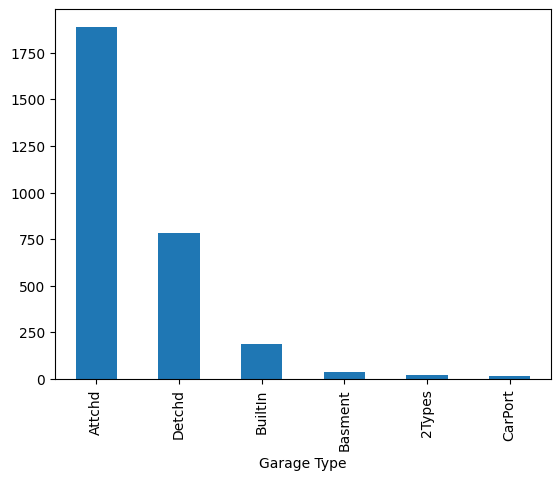

In [27]:
df['Garage Type'].value_counts().plot(kind='bar')

/var/folders/4r/r54s3_591ybgs6zwhwsjs1z00000gn/T/ipykernel_59747/1064045038.py:7: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(lines,labels=['Original','Imputed'],loc='best')


Text(0.5, 1.0, 'Garage Type')

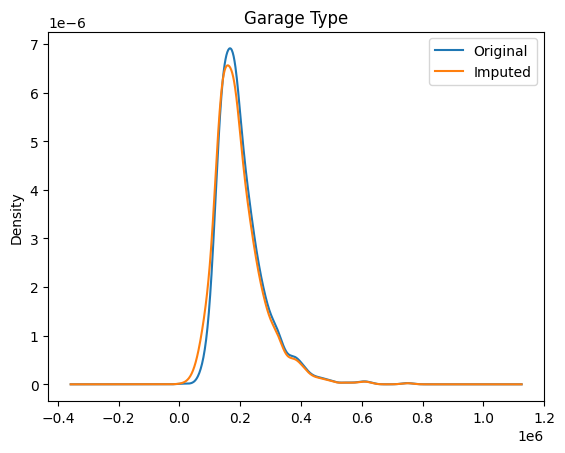

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)
df[df['Garage Type']=='Attchd']['SalePrice'].plot(kind='kde',ax=ax)
lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels=['Original','Imputed'],loc='best')
plt.title('Garage Type')
#The PDA didn't change much, can be a good column to apply this imputation

In [35]:
#Now using sklearn

In [36]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

In [37]:
from sklearn.model_selection import train_test_split
X_train1,X_test1,y_train1,y_test1 = train_test_split(X,y,test_size=0.2)

In [38]:
impute2 = SimpleImputer(strategy='most_frequent')

In [39]:
X_train1[['Garage Type']] = impute2.fit_transform(X_train1[['Garage Type']])
X_test1[['Garage Type']] = impute2.transform(X_test1[['Garage Type']])

In [40]:
impute2.statistics_

array(['Attchd'], dtype=object)